# Business Problem
A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods.
The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.


### Desired Outcome:
The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [6]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [7]:
df = pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding='latin1')

# Exploratory Data Analysis (EDA)
- Load and understand the dataset structure (rows, columns, data types)
- Identify missing values and duplicates
- Data Cleaning
- Explore categorical variables and their distributions
- Calculate key metrics like order processing time and delays

In [9]:
# Overview
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [10]:
# Data Cleaning
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order', # identical to Order Profit Per Order
    'Product Status', # have only one value,
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market']

# dropping columns that are either fully missing, redundant, or have only one value (and thus no variance)
df = df.drop(columns=columns_to_drop)

# removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

#  Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [11]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [12]:
# calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


# Data Analysis and Visualization (Solving Research Questions)
- Visualize profitability distribution
- Calculate delivery time KPIs (total orders, late deliveries, delay %, 90% delay)
- Analyze profit metrics by delay days
- Visualize delay distribution and profit analysis
- Explore delay patterns by categories (region, segment, shipping mode, etc.)
- Identify top drivers of delays in specific regions
- Analyze delay trends by time factors (month, day of week, hour)
- Investigate profitability vs delivery performance

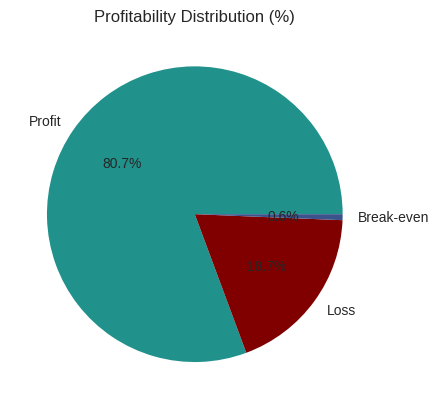

In [13]:
# Profitability Flag based on Order Profit Per Order
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Profitability Flag'].value_counts()

# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

# Business KPIs

In [14]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df= df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")



--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


# Profitability vs Delivery Time Analysis


Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


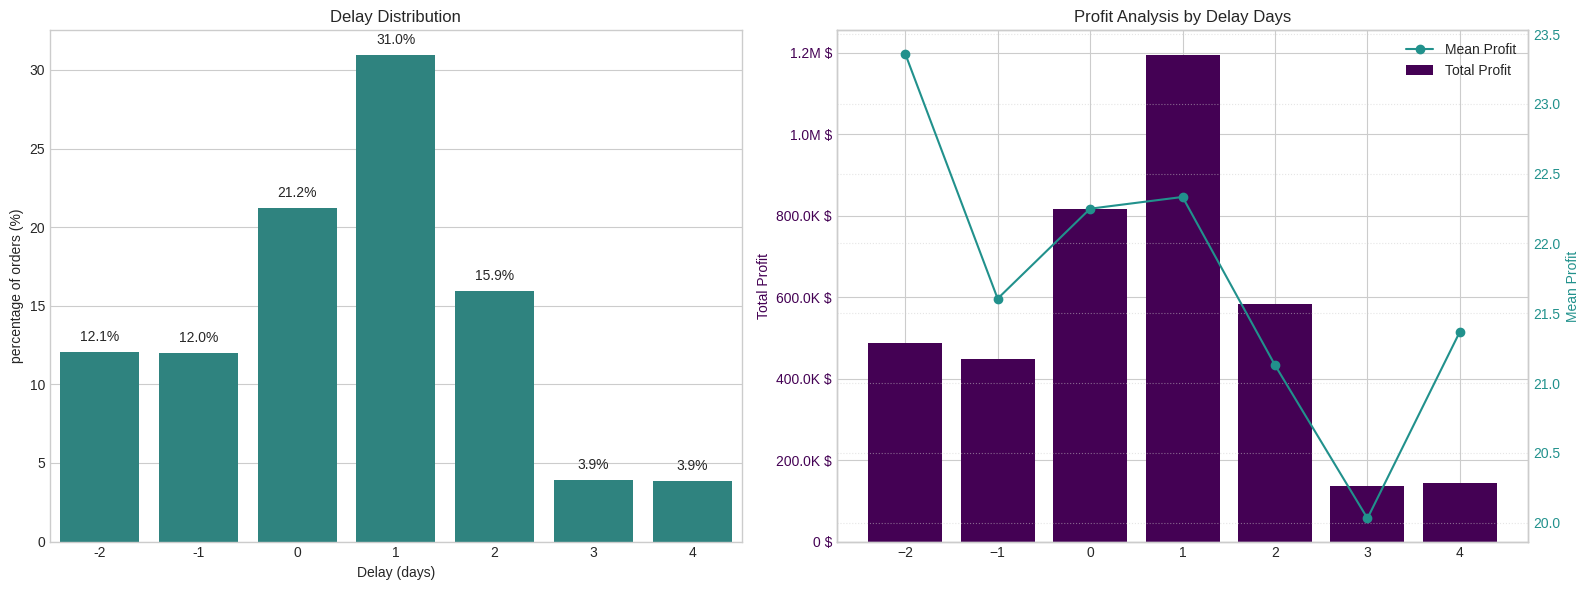

In [15]:
# Avg Profit per Delay Day (Decision Metric)
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
      .agg(
          mean_profit='mean',
          total_profit='sum',
          order_count='count'
      )
      .reset_index()
)

delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days',y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)


# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Bottleneck Detection

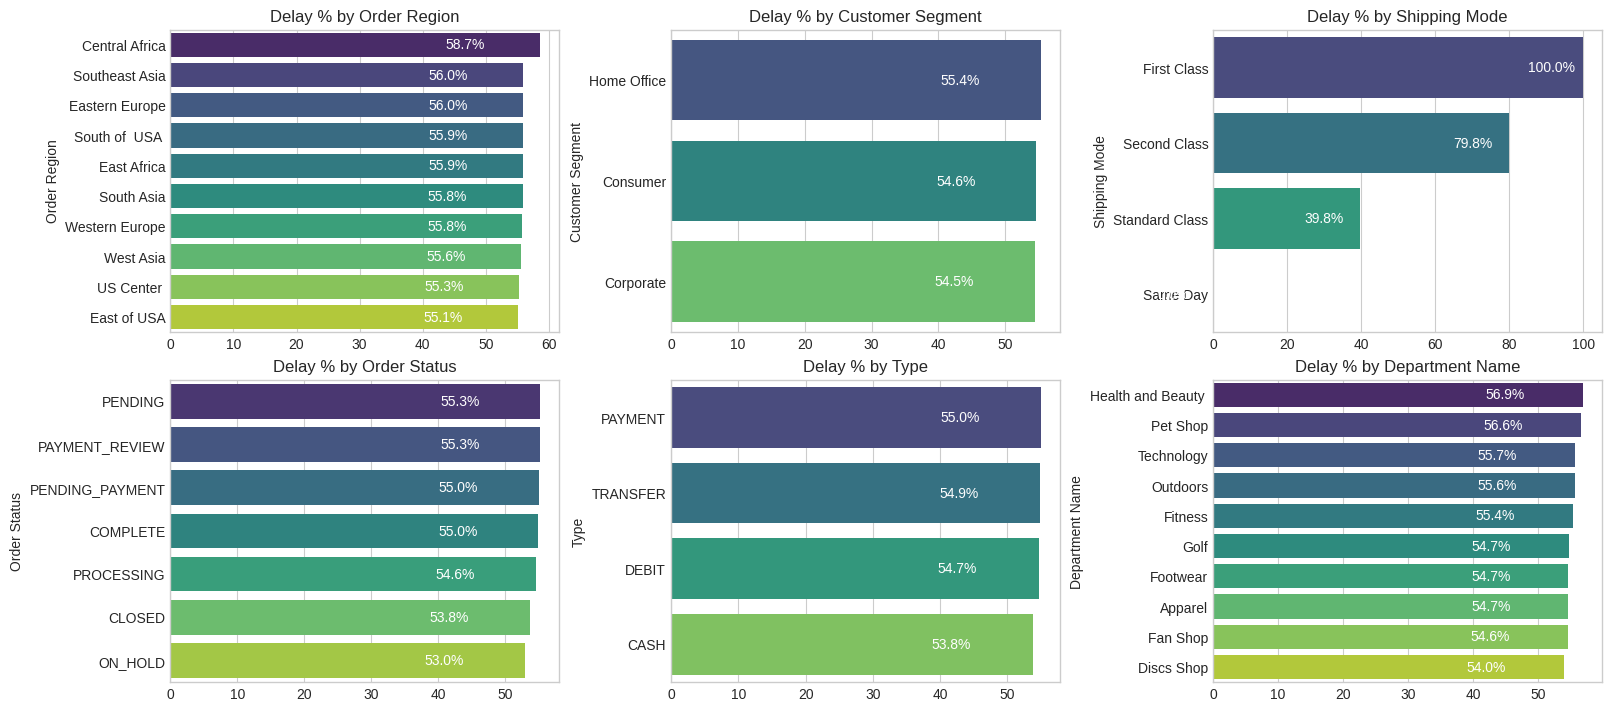

In [16]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status','Type','Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color = 'white')

plt.show()

# Root Cause Analysis

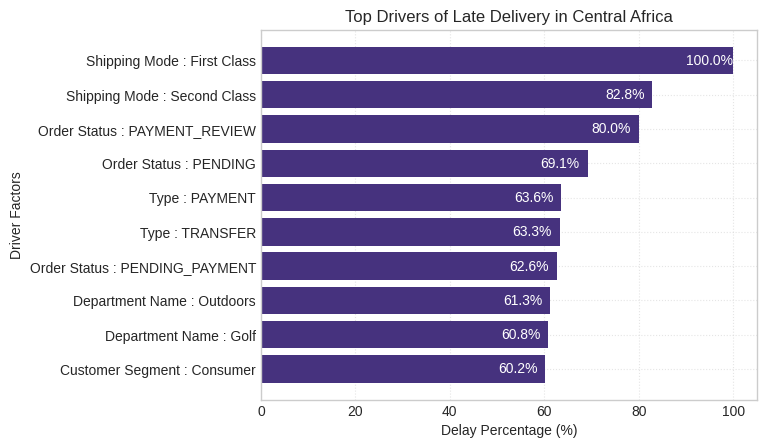

In [17]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name','Type', 'Order Status']

    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay','count'),
                late_orders=('Is_Delayed','sum'),
                avg_delay=('Delay','mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()

    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                f"{width:.1f}%",
                va='center', fontsize = 10,color = 'white')

    plt.show()

top_drivers_for_region('Central Africa')

# Time-Based Analysis

In [18]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

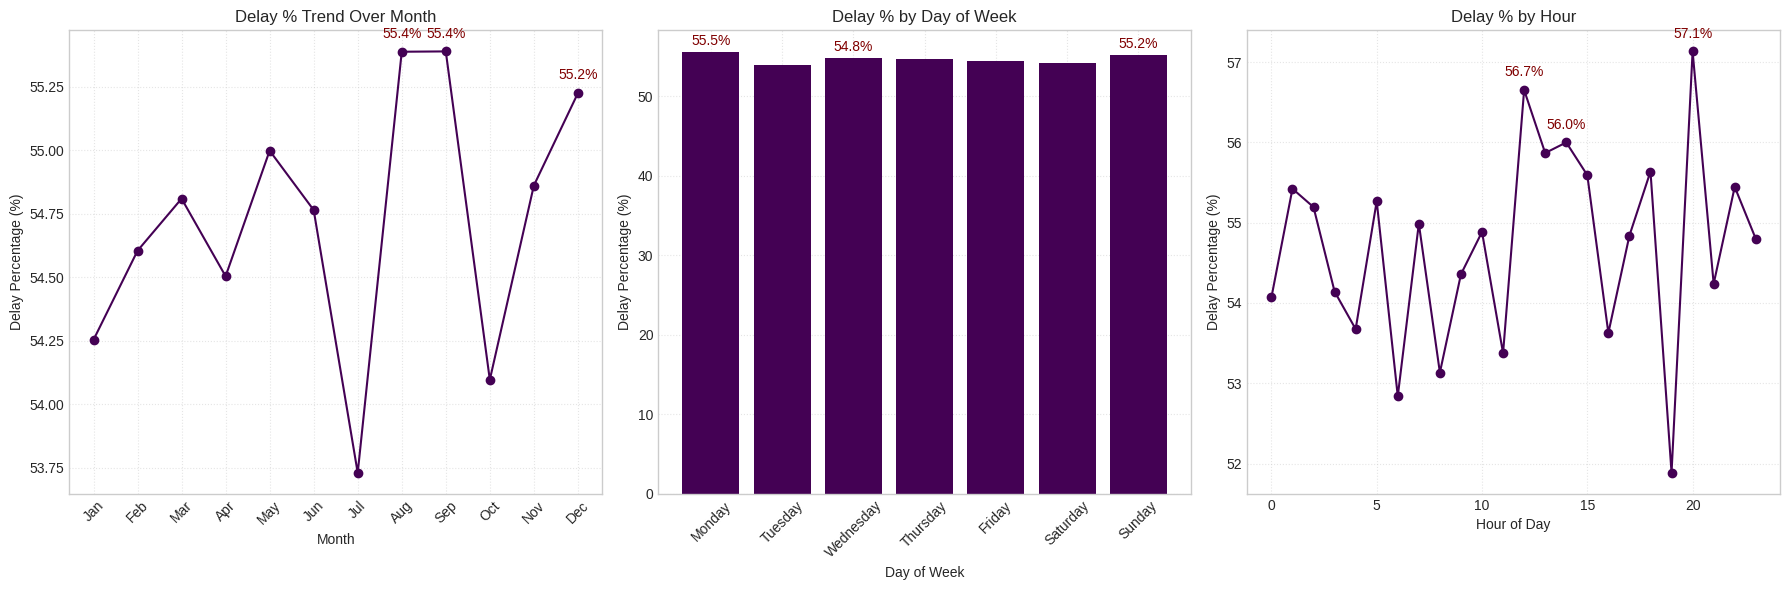

In [19]:
ig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

# Machine Learning Modeling
- Prepare features for modeling (select relevant columns)
- Encode categorical variables using frequency encoding (to avoid high dimensionality)
- Split data into train/test sets with stratification
- Handle class imbalance using SMOTE oversampling
- Train and evaluate Logistic Regression and Random Forest models
- Assess model performance with accuracy, precision, recall, ROC-AUC

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [21]:
X = df[['Type','Days for shipment (scheduled)','Category Name','Customer Segment','Department Name','Order Region','Shipping Mode','order_month','order_hour']]
y = df['Late_delivery_risk']


In [22]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# use encoded features for modeling
X = X_encoded

# train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


In [23]:
# Balancing the training data using SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [24]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred),2))
    print("Precision:", round(precision_score(y_true, y_pred),2))
    print("Recall:", round(recall_score(y_true, y_pred),2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [25]:
# Fit the Random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy: 0.74
Precision: 0.79
Recall: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553

